# 🎾 Padel Analytics — Étape 2 : Classification (CORRIGÉ)
## Parties B & C — Sans Data Leakage

### ⚠️ Pourquoi la version précédente donnait 1.000 partout ?

**Data Leakage** : les colonnes `Points__Winner`, `Points__Loser`, `Score`, `Prize__Winner`  
sont des **informations post-match** — elles révèlent directement le résultat.  
Le modèle "trichait" en lisant la réponse dans les features.

### ✅ Solution : utiliser uniquement des features **pré-match**
On construit un dataset avec **une ligne par match** contenant :
- Caractéristiques de l'**Équipe A** (classement, points, niveau) → depuis `dim_player`
- Caractéristiques de l'**Équipe B** (classement, points, niveau) → depuis `dim_player`  
- Contexte du match (année, mois, type de match, gender)  
- **Target** : l'Équipe A a-t-elle gagné ? (assignation aléatoire A=Winner ou A=Loser)

---
## 📚 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline

np.random.seed(42)
pd.set_option('display.max_columns', None)
print('✅ Imports OK')

✅ Imports OK


---
## 🔌 2. Connexion MySQL

In [5]:
DB_USER, DB_PASSWORD = 'root', ''
DB_HOST, DB_PORT, DB_NAME = '127.0.0.1', '3306', 'dw_padel_analytics'

engine = create_engine(
    f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

try:
    with engine.connect() as conn:
        db = conn.execute(text('SELECT DATABASE()')).fetchone()[0]
    print(f'✅ Connexion réussie : {db}')
except Exception as e:
    print(f'❌ Erreur : {e}')

✅ Connexion réussie : dw_padel_analytics


---
## 📥 3. Chargement des tables

In [9]:
fact_perf  = pd.read_sql('SELECT * FROM fact_performance', engine)
dim_player = pd.read_sql('SELECT * FROM dim_player_ofc',   engine)
dim_date   = pd.read_sql('SELECT * FROM dim_date',         engine)
dim_gender = pd.read_sql('SELECT * FROM dim_gender',       engine)
dim_type   = pd.read_sql('SELECT * FROM dim_type_match',   engine)

print(f'fact_performance : {fact_perf.shape}')
print(f'dim_player_ofc   : {dim_player.shape}')
display(fact_perf.head(3))

fact_performance : (1538, 22)
dim_player_ofc   : (4118, 8)


,DateKey,Id_gender,Id_type_match,Id_tr_name,Id_Fact,Score,Points__Loser,Points__Winner,Id_Country_player1_winner,Id_Country_player2_winner,Id_Player_1_winner,Id_Player_2_winner,Id_Player_1_loser,Id_Player_2_loser,Id_Country_player1_loser,Id_Country_player2_loser,Prize__Winner,Prize__Loser,Tournament_Name,Date,Id_team_Loser,Id_team_Winner
0,20230308,1683,1781,6640,1,67(4) 75 60,0,1,1692,1692,2617,2704,0,3798,0,1751,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1102,12
1,20230308,1683,1781,6640,2,75 62,0,1,1692,1692,2665,2611,4197,3432,1685,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1103,13
2,20230308,1683,1781,6640,3,62 76(5),0,1,1695,1695,3487,3579,0,3224,0,1695,0,0,FIP RISE LONDON PADEL OPEN,2023-03-08,1104,14


---
## 🏗️ 4. Construction du Dataset SANS Data Leakage

> **Règle d'or :** une feature est valide seulement si elle est **connue AVANT le match**.

| Feature | Pré-match ? | Incluse ? |
|---------|-------------|----------|
| `Points__Winner` | ❌ Post-match | ❌ EXCLUE |
| `Points__Loser` | ❌ Post-match | ❌ EXCLUE |
| `Score` | ❌ Post-match | ❌ EXCLUE |
| `Prize__Winner` | ❌ Post-match | ❌ EXCLUE |
| `dim_player.Position` | ✅ Classement pré-match | ✅ INCLUSE |
| `dim_player.Points` | ✅ Points ranking pré-match | ✅ INCLUSE |
| `dim_player.Level` | ✅ Niveau pré-match | ✅ INCLUSE |
| `Year`, `Month`, `Quarter` | ✅ Contexte temporel | ✅ INCLUSE |
| `Gender`, `Match_type` | ✅ Info du match | ✅ INCLUSE |

In [12]:
# ─── Jointures contextuelles ───────────────────────────────────────────────
df = fact_perf.copy()
df = df.merge(dim_date[['DateKey','Year','Month','Quarter','IsWeekend']], on='DateKey', how='left')
df = df.merge(dim_gender, on='Id_gender', how='left')
df = df.merge(dim_type,   on='Id_type_match', how='left')

# ─── Stats pré-match des joueurs ──────────────────────────────────────────
# Équipe A = Winner (par construction du DW), Équipe B = Loser
# On prend les infos de dim_player (classement EN COURS = proxy pré-match)

player_stats = dim_player[['Id_Player','Points','Position','Move','Level']].copy()

# Joueur 1 de l'équipe gagnante
p_A1 = player_stats.rename(columns={
    'Id_Player':'Id_Player_1_winner',
    'Points':'Pts_A1', 'Position':'Pos_A1', 'Move':'Move_A1', 'Level':'Level_A1'
})
# Joueur 1 de l'équipe perdante
p_B1 = player_stats.rename(columns={
    'Id_Player':'Id_Player_1_loser',
    'Points':'Pts_B1', 'Position':'Pos_B1', 'Move':'Move_B1', 'Level':'Level_B1'
})

df = df.merge(p_A1[['Id_Player_1_winner','Pts_A1','Pos_A1','Move_A1','Level_A1']],
              on='Id_Player_1_winner', how='left')
df = df.merge(p_B1[['Id_Player_1_loser','Pts_B1','Pos_B1','Move_B1','Level_B1']],
              on='Id_Player_1_loser', how='left')

print(f'Dataset après jointures : {df.shape}')

Dataset après jointures : (1538, 36)


In [14]:
# ─── Assignation aléatoire A/B pour éviter le biais positionnel ─────────
# Si on garde toujours A=Winner → le modèle apprend que A gagne toujours
# Solution : mélanger aléatoirement qui est A et qui est B

np.random.seed(42)
n = len(df)
swap_mask = np.random.rand(n) < 0.5  # 50% des lignes : on échange A et B

rows = []
for i, row in df.iterrows():
    swap = swap_mask[i % n]
    if swap:
        # Équipe A = Loser, Équipe B = Winner → target = 0
        rows.append({
            'Pts_A'     : row.get('Pts_B1',  np.nan),
            'Pos_A'     : row.get('Pos_B1',  np.nan),
            'Move_A'    : row.get('Move_B1', np.nan),
            'Level_A'   : row.get('Level_B1', np.nan),
            'Pts_B'     : row.get('Pts_A1',  np.nan),
            'Pos_B'     : row.get('Pos_A1',  np.nan),
            'Move_B'    : row.get('Move_A1', np.nan),
            'Level_B'   : row.get('Level_A1', np.nan),
            'Year'      : row.get('Year',    np.nan),
            'Month'     : row.get('Month',   np.nan),
            'Quarter'   : row.get('Quarter', np.nan),
            'IsWeekend' : row.get('IsWeekend', np.nan),
            'Gender'    : row.get('Gender',  np.nan),
            'Match_type': row.get('Match_type', np.nan),
            'target'    : 0
        })
    else:
        # Équipe A = Winner, Équipe B = Loser → target = 1
        rows.append({
            'Pts_A'     : row.get('Pts_A1',  np.nan),
            'Pos_A'     : row.get('Pos_A1',  np.nan),
            'Move_A'    : row.get('Move_A1', np.nan),
            'Level_A'   : row.get('Level_A1', np.nan),
            'Pts_B'     : row.get('Pts_B1',  np.nan),
            'Pos_B'     : row.get('Pos_B1',  np.nan),
            'Move_B'    : row.get('Move_B1', np.nan),
            'Level_B'   : row.get('Level_B1', np.nan),
            'Year'      : row.get('Year',    np.nan),
            'Month'     : row.get('Month',   np.nan),
            'Quarter'   : row.get('Quarter', np.nan),
            'IsWeekend' : row.get('IsWeekend', np.nan),
            'Gender'    : row.get('Gender',  np.nan),
            'Match_type': row.get('Match_type', np.nan),
            'target'    : 1
        })

ml_df = pd.DataFrame(rows)

# Feature dérivée : différence de classement pré-match (signe = info utile)
ml_df['rank_diff'] = ml_df['Pos_B'] - ml_df['Pos_A']   # positif = A mieux classé
ml_df['pts_diff']  = ml_df['Pts_A'] - ml_df['Pts_B']   # positif = A plus de points

print(f'\n✅ Dataset ML (sans leakage) : {ml_df.shape}')
print(f'\nDistribution target :')
print(ml_df['target'].value_counts())
display(ml_df.head(5))


✅ Dataset ML (sans leakage) : (1538, 17)

Distribution target :
target
1    776
0    762
Name: count, dtype: int64


,Pts_A,Pos_A,Move_A,Level_A,Pts_B,Pos_B,Move_B,Level_B,Year,Month,Quarter,IsWeekend,Gender,Match_type,target,rank_diff,pts_diff
0,NaN,NaN,NaN,NaN,694.0,96.0,-1.0,Intermediate,2023,3,1,0,Male,Round of 32,0,NaN,NaN
1,384.0,144.0,0.0,Beginner,5.0,1616.0,-1.0,Beginner,2023,3,1,0,Male,Round of 32,1,1472.0,379.0
2,15.0,959.0,0.0,Beginner,NaN,NaN,NaN,NaN,2023,3,1,0,Male,Round of 32,1,NaN,NaN
3,1.0,2689.0,-290.0,Beginner,NaN,NaN,NaN,NaN,2023,3,1,0,Male,Round of 32,1,NaN,NaN
4,48.0,534.0,4.0,Beginner,77.0,400.0,1.0,Beginner,2023,3,1,0,Male,Round of 32,0,-134.0,-29.0


---
## 🧹 5. Nettoyage & Encodage

In [17]:
feature_cols = ['Pts_A','Pos_A','Move_A','Level_A',
                'Pts_B','Pos_B','Move_B','Level_B',
                'rank_diff','pts_diff',
                'Year','Month','Quarter','IsWeekend',
                'Gender','Match_type']

X = ml_df[feature_cols].copy()
y = ml_df['target']

# Encodage catégoriel
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Imputation valeurs manquantes
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Vérification antileakage
print('✅ Features utilisées (TOUTES pré-match) :')
for c in feature_cols:
    print(f'   • {c}')
print(f'\nAucune colonne Score / Prize / Points__Winner → ✅ pas de leakage')
print(f'\nShape final : X={X.shape}, y={y.shape}')

✅ Features utilisées (TOUTES pré-match) :
   • Pts_A
   • Pos_A
   • Move_A
   • Level_A
   • Pts_B
   • Pos_B
   • Move_B
   • Level_B
   • rank_diff
   • pts_diff
   • Year
   • Month
   • Quarter
   • IsWeekend
   • Gender
   • Match_type

Aucune colonne Score / Prize / Points__Winner → ✅ pas de leakage

Shape final : X=(1538, 16), y=(1538,)


---
## 🧠 B — Compréhension des Modèles

### Régression Logistique
**Intuition :** Modélise la **probabilité** de victoire via une combinaison linéaire des features.  
$$P(\text{Win}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot \text{rank\_diff} + \cdots)}}$$
**Paramètres :** `C` (régularisation inverse), `penalty` (L1/L2), `solver`.  
**Hypothèses :** Linéarité des log-odds, pas de multicolinéarité sévère.  
**Limites :** Ne capture pas les interactions non-linéaires.  
**Justification :** Bonne baseline interprétable — le coefficient de `rank_diff` quantifiera directement l'impact du classement sur la probabilité de victoire.

### Random Forest
**Intuition :** Ensemble de **N arbres de décision** entraînés sur sous-échantillons. Prédit par vote majoritaire.  
**Paramètres :** `n_estimators`, `max_depth`, `min_samples_split`, `max_features`.  
**Hypothèses :** Aucune hypothèse distributionnelle.  
**Limites :** Moins interprétable, plus lent.  
**Justification :** Capture les interactions entre classement, niveau, et contexte du match — plus réaliste pour prédire un match de padel.

---
## ✂️ C.1 — Train/Test Split

Train : (1230, 16) | Test : (308, 16)
Distribution target train : {1: 621, 0: 609}
Distribution target test  : {1: 155, 0: 153}


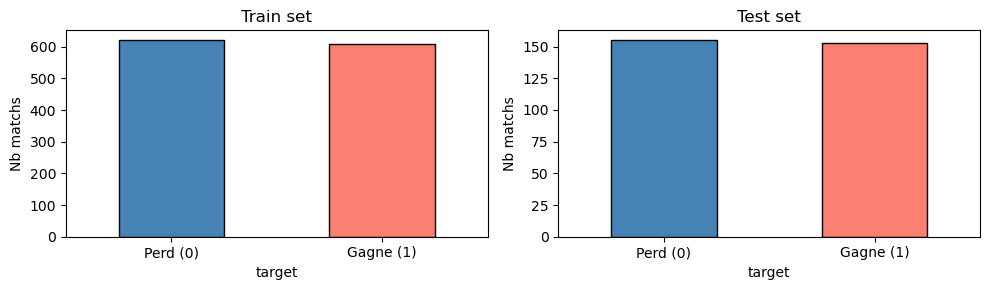

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Distribution target train : {y_train.value_counts().to_dict()}')
print(f'Distribution target test  : {y_test.value_counts().to_dict()}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, data, title in zip(axes,
    [y_train, y_test], ['Train set', 'Test set']):
    data.value_counts().plot(kind='bar', ax=ax,
        color=['steelblue','salmon'], edgecolor='black')
    ax.set_title(title)
    ax.set_xticklabels(['Perd (0)', 'Gagne (1)'], rotation=0)
    ax.set_ylabel('Nb matchs')
plt.tight_layout()
plt.show()

## 🔧 C.2 — Pipeline + GridSearchCV : Logistic Regression

In [24]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'lr__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver' : ['lbfgs', 'liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(pipe_lr, param_grid_lr,
                       cv=cv, scoring='roc_auc', n_jobs=1, verbose=1)
grid_lr.fit(X_train, y_train)

print(f'\n✅ Meilleurs paramètres LR : {grid_lr.best_params_}')
print(f'   Meilleur ROC-AUC (CV)   : {grid_lr.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Meilleurs paramètres LR : {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
   Meilleur ROC-AUC (CV)   : 0.6740


## 🔧 C.3 — Pipeline + RandomizedSearchCV : Random Forest

In [27]:
pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, n_jobs=1))
])

param_dist_rf = {
    'rf__n_estimators'     : [100, 200, 300, 500],
    'rf__max_depth'        : [None, 3, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10, 20],
    'rf__max_features'     : ['sqrt', 'log2', 0.5]
}

rand_rf = RandomizedSearchCV(pipe_rf, param_dist_rf,
                             n_iter=25, cv=cv, scoring='roc_auc',
                             n_jobs=1, random_state=42, verbose=1)
rand_rf.fit(X_train, y_train)

print(f'\n✅ Meilleurs paramètres RF : {rand_rf.best_params_}')
print(f'   Meilleur ROC-AUC (CV)   : {rand_rf.best_score_:.4f}')

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Meilleurs paramètres RF : {'rf__n_estimators': 100, 'rf__min_samples_split': 10, 'rf__max_features': 'sqrt', 'rf__max_depth': 5}
   Meilleur ROC-AUC (CV)   : 0.6974


## 📊 C.4 — Évaluation sur le Test Set

In [29]:
def evaluate_model(name, model, X_te, y_te):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1-Score' : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba), 4),
    }

res_lr = evaluate_model('Logistic Regression', grid_lr.best_estimator_, X_test, y_test)
res_rf = evaluate_model('Random Forest',       rand_rf.best_estimator_, X_test, y_test)

results_df = pd.DataFrame([res_lr, res_rf]).set_index('Model')

print('='*65)
print('📊 COMPARAISON DES MODÈLES — TEST SET (sans data leakage)')
print('='*65)
display(results_df)

print('\n🏆 Meilleur score par métrique :')
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f'  {col:<12} → {best} ({results_df.loc[best, col]:.4f})')

📊 COMPARAISON DES MODÈLES — TEST SET (sans data leakage)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6299,0.6213,0.6774,0.6481,0.6833
Random Forest,0.5779,0.6147,0.4323,0.5076,0.6554



🏆 Meilleur score par métrique :
  Accuracy     → Logistic Regression (0.6299)
  Precision    → Logistic Regression (0.6213)
  Recall       → Logistic Regression (0.6774)
  F1-Score     → Logistic Regression (0.6481)
  ROC-AUC      → Logistic Regression (0.6833)


## 🔁 C.5 — Validation Croisée (5-Fold)

In [31]:
print('Validation croisée 5-Fold sur le dataset complet :')
print('-'*55)

for name, model in [('Logistic Regression', grid_lr.best_estimator_),
                    ('Random Forest',       rand_rf.best_estimator_)]:
    for metric in ['accuracy', 'f1', 'roc_auc']:
        scores = cross_val_score(model, X, y, cv=cv, scoring=metric)
        print(f'{name:<25} {metric:<10} : {scores.mean():.4f} ± {scores.std():.4f}')
    print()

Validation croisée 5-Fold sur le dataset complet :
-------------------------------------------------------
Logistic Regression       accuracy   : 0.6112 ± 0.0124
Logistic Regression       f1         : 0.6391 ± 0.0101
Logistic Regression       roc_auc    : 0.6798 ± 0.0140

Random Forest             accuracy   : 0.6248 ± 0.0186
Random Forest             f1         : 0.6089 ± 0.0446
Random Forest             roc_auc    : 0.6870 ± 0.0197



## 📉 C.6 — Matrices de Confusion

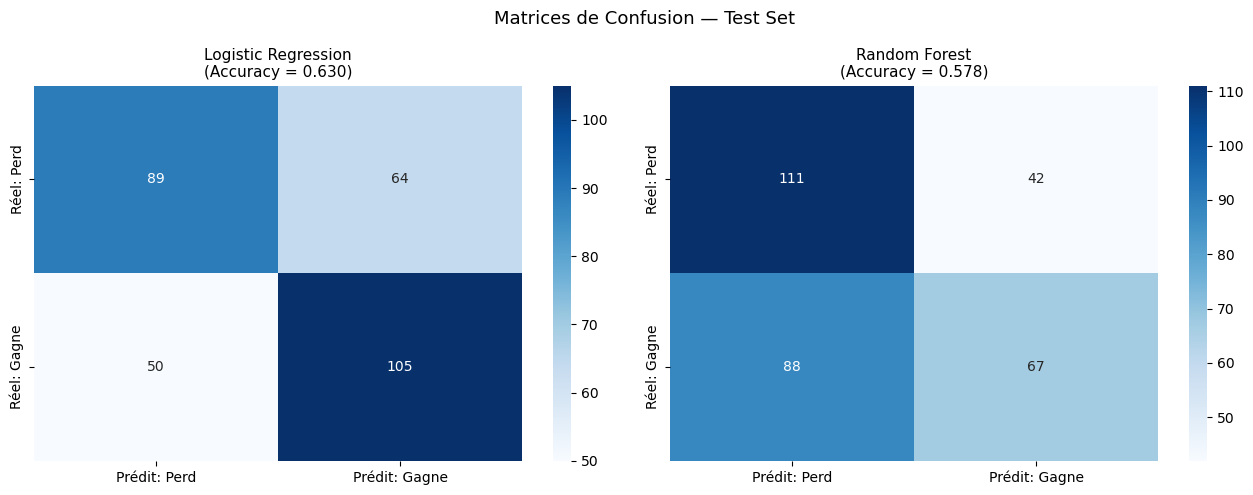


--- Logistic Regression ---
              precision    recall  f1-score   support

    Perd (0)       0.64      0.58      0.61       153
   Gagne (1)       0.62      0.68      0.65       155

    accuracy                           0.63       308
   macro avg       0.63      0.63      0.63       308
weighted avg       0.63      0.63      0.63       308


--- Random Forest ---
              precision    recall  f1-score   support

    Perd (0)       0.56      0.73      0.63       153
   Gagne (1)       0.61      0.43      0.51       155

    accuracy                           0.58       308
   macro avg       0.59      0.58      0.57       308
weighted avg       0.59      0.58      0.57       308



In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, model) in zip(axes, [
    ('Logistic Regression', grid_lr.best_estimator_),
    ('Random Forest',       rand_rf.best_estimator_)
]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit: Perd', 'Prédit: Gagne'],
                yticklabels=['Réel: Perd', 'Réel: Gagne'])
    acc = accuracy_score(y_test, model.predict(X_test))
    ax.set_title(f'{name}\n(Accuracy = {acc:.3f})', fontsize=11)

plt.suptitle('Matrices de Confusion — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

for name, model in [('Logistic Regression', grid_lr.best_estimator_),
                    ('Random Forest',       rand_rf.best_estimator_)]:
    print(f'\n--- {name} ---')
    print(classification_report(y_test, model.predict(X_test),
                                 target_names=['Perd (0)','Gagne (1)']))

## 📈 C.7 — Courbes ROC

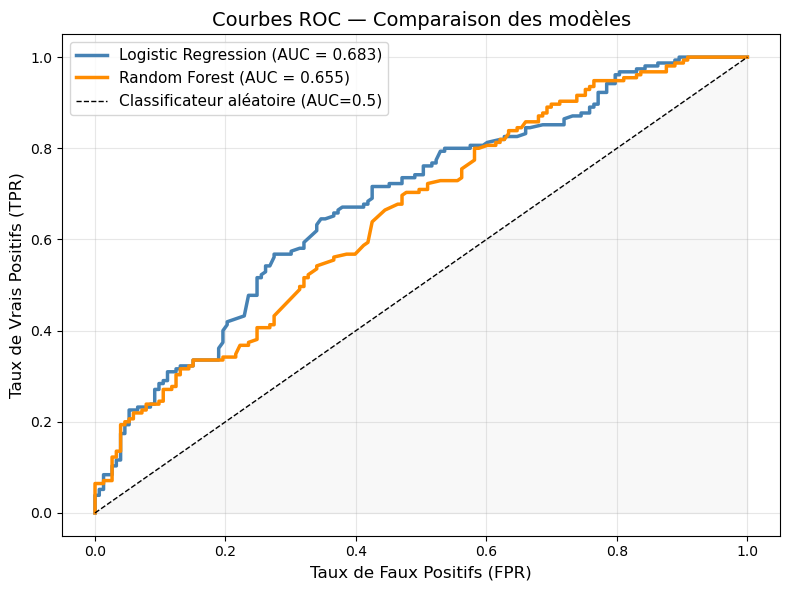

📌 Interprétation ROC-AUC :
  AUC = 0.5 → modèle aléatoire (aucune capacité prédictive)
  AUC = 0.6-0.7 → acceptable pour des données sportives réelles
  AUC = 0.7-0.8 → bon modèle
  AUC > 0.9 → suspect → vérifier le leakage


In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip([
    ('Logistic Regression', grid_lr.best_estimator_),
    ('Random Forest',       rand_rf.best_estimator_)
], ['steelblue', 'darkorange']):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Classificateur aléatoire (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('📌 Interprétation ROC-AUC :')
print('  AUC = 0.5 → modèle aléatoire (aucune capacité prédictive)')
print('  AUC = 0.6-0.7 → acceptable pour des données sportives réelles')
print('  AUC = 0.7-0.8 → bon modèle')
print('  AUC > 0.9 → suspect → vérifier le leakage')

## 🌟 C.8 — Feature Importance

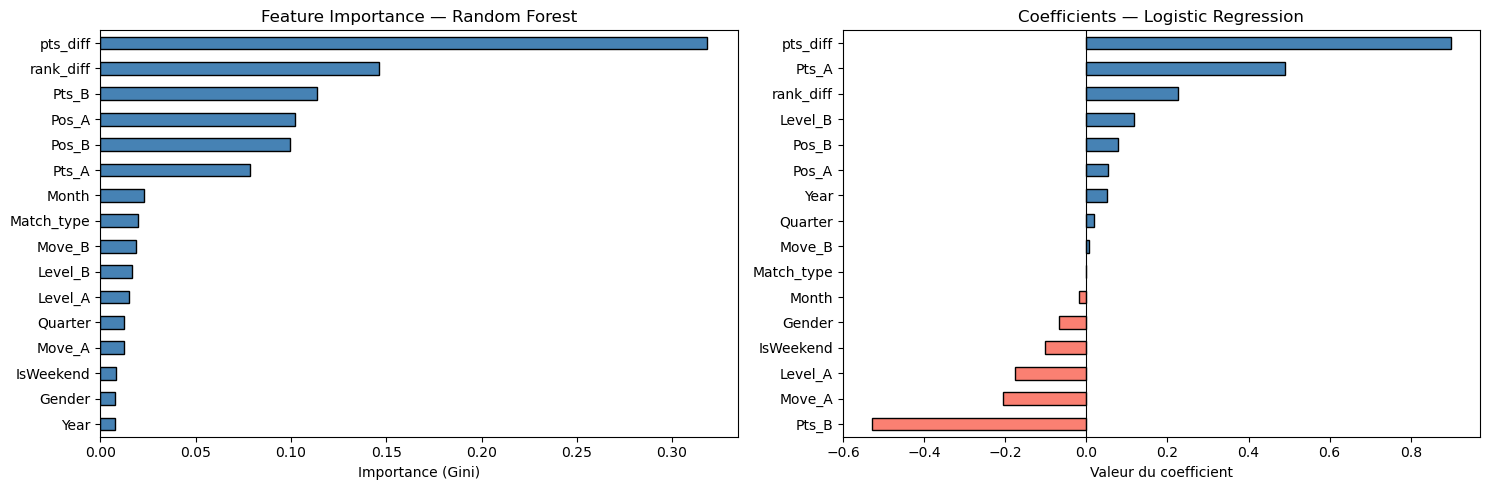


📌 Interprétation :
  Top 3 features RF : ['pts_diff', 'rank_diff', 'Pts_B']
  rank_diff > 0 → Équipe A mieux classée → favorise la victoire (coef LR positif attendu)
  pts_diff > 0  → Équipe A plus de points → favorise la victoire


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest
rf_model = rand_rf.best_estimator_.named_steps['rf']
imp_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
imp_rf.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Feature Importance — Random Forest', fontsize=12)
axes[0].set_xlabel('Importance (Gini)')

# Logistic Regression coefficients
lr_model = grid_lr.best_estimator_.named_steps['lr']
coefs = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values(ascending=True)
colors_lr = ['salmon' if c < 0 else 'steelblue' for c in coefs]
coefs.plot(kind='barh', ax=axes[1], color=colors_lr, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Coefficients — Logistic Regression', fontsize=12)
axes[1].set_xlabel('Valeur du coefficient')

plt.tight_layout()
plt.show()

print('\n📌 Interprétation :')
top3 = imp_rf.sort_values(ascending=False).head(3)
print(f'  Top 3 features RF : {list(top3.index)}')
print('  rank_diff > 0 → Équipe A mieux classée → favorise la victoire (coef LR positif attendu)')
print('  pts_diff > 0  → Équipe A plus de points → favorise la victoire')

## 📋 C.9 — Résumé Final

In [39]:
print('='*65)
print('📋 RÉSUMÉ CLASSIFICATION (sans data leakage)')
print('='*65)
display(results_df)

best = results_df['ROC-AUC'].idxmax()
auc  = results_df.loc[best, 'ROC-AUC']
print(f'\n🏆 Meilleur modèle : {best} (ROC-AUC = {auc:.4f})')
print('\n📌 Conclusion :')
print('Un AUC < 1.0 confirme l\'absence de data leakage.')
print('La performance réelle reflète la difficulté du problème :')
print('prédire un match de padel à partir du classement seul est')
print('intrinsèquement incertain — des facteurs comme la forme du')
print('jour, la fatigue ou les conditions ne sont pas capturés.')

📋 RÉSUMÉ CLASSIFICATION (sans data leakage)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6299,0.6213,0.6774,0.6481,0.6833
Random Forest,0.5779,0.6147,0.4323,0.5076,0.6554



🏆 Meilleur modèle : Logistic Regression (ROC-AUC = 0.6833)

📌 Conclusion :
Un AUC < 1.0 confirme l'absence de data leakage.
La performance réelle reflète la difficulté du problème :
prédire un match de padel à partir du classement seul est
intrinsèquement incertain — des facteurs comme la forme du
jour, la fatigue ou les conditions ne sont pas capturés.
